In [1]:
import torch
import random
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

In [2]:
# ---------------------------------------------------------------------------*/
# - prepare a dataset

# define known data properties
timeseries_len  = 101
timestep        = 0.0001
dataset_dir     = 'cavity'

# read data from files
data_train = utils.read_datafile(f'{dataset_dir}/train1', timeseries_len)
data_valid = utils.read_datafile(f'{dataset_dir}/valid', timeseries_len)
data_test = utils.read_datafile(f'{dataset_dir}/test', timeseries_len)

data_dims_n = data_train.shape[-1] - 1
ctr_dims_n = 1

# compile dataset parameters
data_table = [
    ( 'dataset',           'batches',        'timeseries length',          'channels'),
    ('--------',           '-------',        '-----------------',          '--------'),
    (   'train', data_train.shape[0], data_train.shape[1], data_train.shape[2]),
    (   'valid', data_valid.shape[0], data_valid.shape[1], data_valid.shape[2]),
    (    'test',  data_test.shape[0],  data_test.shape[1],  data_test.shape[2]) ]

# print dataset parameters
print('inf >> dataset parameters:')
print('')
for row in data_table:
    print(f'{row[0]:>8} {row[1]:>8} {row[2]:>18} {row[3]:>8}')

inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                101        3
   valid     1000                101        3
    test      500                101        3


torch.Size([101, 3])


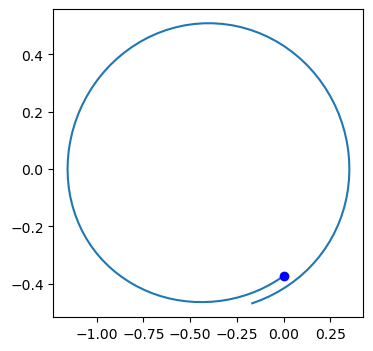

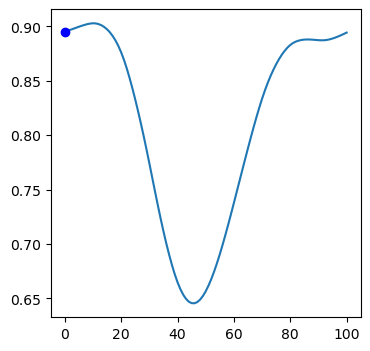

In [3]:
data_i = 44
data_viz = data_test[data_i]
print(data_viz.shape)

plt.figure(figsize=(4, 4))
plt.plot(data_viz[:,0], data_viz[:,1])
plt.plot(data_viz[0, 0], data_viz[0, 1], '--bo')
plt.show()

plt.figure(figsize=(4, 4))
plt.plot(data_viz[:,2])
plt.plot(data_viz[0, 2], '--bo')
plt.show()

In [4]:
# ---------------------------------------------------------------------------*/
# - instantiate dynamic mode decomposition

print(f'inf >> number of data dimensions is {data_dims_n}')
print(f'inf >> number of control dimensions is {ctr_dims_n}')

config = {
    'data_dims_n'            : data_dims_n,
    'ctr_dims_n'             : ctr_dims_n,

    'modes'                  : [(2*torch.pi*100., 1)],

    'timestep'               : timestep,
    'horizon'                : 101,
    'batch_size'             : 64,
    'loss_hp_pred'           : 1e1,
    'loss_hp_recon'          : 1e0,
    'loss_hp_mode'           : 1e-1,
    'loss_hp_sparse_weights' : 0,
    'loss_hp_big_weights'    : 1e-3
}

model = care.deep_koopman(config)

inf >> number of data dimensions is 2
inf >> number of control dimensions is 1


In [5]:
# ---------------------------------------------------------------------------*/
# - training and validation

batch_size = config['batch_size']

# make validation datasets and loaders
dataset_valid = torch.utils.data.TensorDataset(data_valid)
dataloader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=batch_size, shuffle=False)

# specify optimizer and a loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# specify the length of our validated prediction
prediction_steps_n = timeseries_len

err_train_recon = []
err_train_pred = []
err_train_mode = []

err_valid_recon = []
err_valid_pred = []

ks = []

datafiles_train_n = 3#random.randint(4, 6)
print(f"inf >> Number of data files for training : {datafiles_train_n}")

horizon_valid = config['horizon']

for datafile_train in range(datafiles_train_n):
    print(f"inf >> Processing training file number {datafile_train + 1}")
    data_train = utils.read_datafile(f'{dataset_dir}/train{datafile_train + 1}', timeseries_len)

    # make training datasets and loaders
    dataset_train = torch.utils.data.TensorDataset(data_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

    # train
    for epoch in range(10):

        # train neural networks
        for data in dataloader_train:
            timeseries = data[0][:, :, :2]
            control    = data[0][:, :, 2:]
            #control = torch.zeros(timeseries.shape[0], timeseries.shape[1], 1)

            optimizer.zero_grad()

            loss, err_recon, err_pred, err_mode = model.fit(timeseries, control)
            loss.backward()

            optimizer.step()

            with torch.no_grad():
                err_train_recon.append(err_recon)
                err_train_pred.append(err_pred)
                err_train_mode.append(err_mode)
                ks.append(model.k)

        # validate results
        with torch.no_grad():
            for data in dataloader_valid:
                timeseries = data[0][:, :, :2]
                control    = data[0][:, :, 2:]
                #control = torch.zeros(timeseries.shape[0], timeseries.shape[1], 1)

                # validate prediction
                timeseries_pred = model.predict(timeseries, control, horizon_valid)
                err_valid_pred.append(torch.mean((timeseries[:, :horizon_valid, :] - timeseries_pred)**2))

                # validate reconstruction
                timeseries_recon = model.reconstructor(model.decomposer(timeseries))
                err_valid_recon.append(torch.mean((timeseries - timeseries_recon)**2))


inf >> Number of data files for training : 3
inf >> Processing training file number 1
inf >> Processing training file number 2
inf >> Processing training file number 3


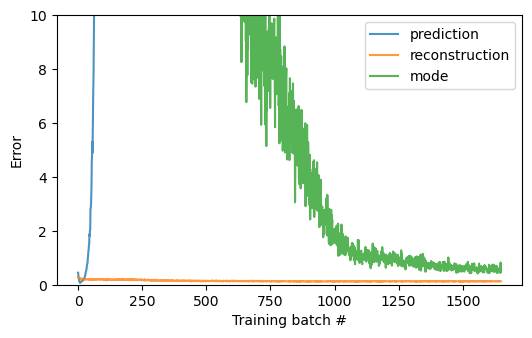

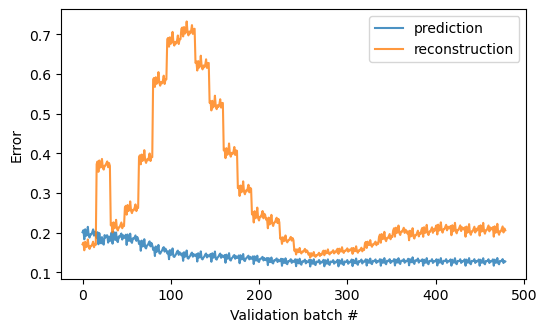

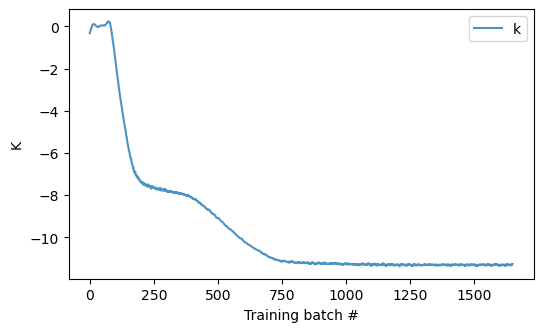

In [6]:
with torch.no_grad():
    plt.figure(figsize=(6, 3.5))
    plt.plot(err_train_pred, alpha=0.8, label='prediction')
    plt.plot(err_train_recon, alpha=0.8, label='reconstruction')
    plt.plot(err_train_mode, alpha=0.8, label='mode')
    plt.xlabel("Training batch #")
    plt.ylabel("Error")
    plt.ylim((0,10))
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 3.5))
    plt.plot(err_valid_pred, alpha=0.8, label='prediction')
    plt.plot(err_valid_recon, alpha=0.8, label='reconstruction')
    plt.xlabel("Validation batch #")
    plt.ylabel("Error")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 3.5))
    plt.plot(ks, alpha=0.8, label='k')
    plt.xlabel("Training batch #")
    plt.ylabel("K")
    plt.legend()
    plt.show()

inf >> Eigenvalue scaling ranges from -2136.35 to -2102.73
inf >> Eigenvalue frequency ranges from 623.64 to 633.60


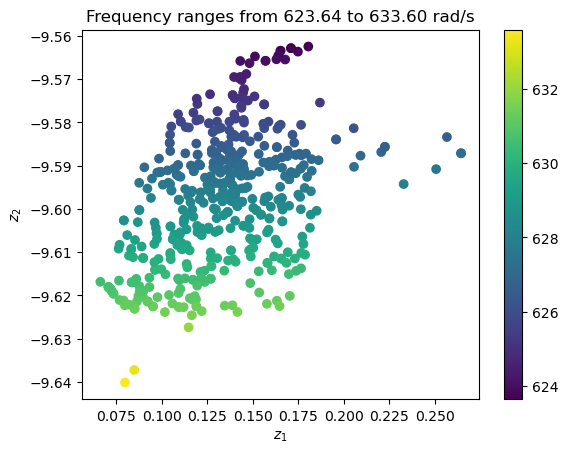

In [7]:
# ---------------------------------------------------------------------------*/
# - test results : check the distribution of frequencies in eigenfunctions

with torch.no_grad():
    eigenfuncs = model.decomposer(model.start_of(data_test[:, :, :2]))
    eigenvalues = model.dynamics(eigenfuncs)

    eigenfuncs = torch.squeeze(eigenfuncs, 1)
    eigenvalues = torch.squeeze(eigenvalues, 1)

    osc_eigenfuncs_n = int(eigenfuncs.shape[1]/len(config['modes']))
    osc_eigenvalues_n = int(eigenvalues.shape[1]/len(config['modes']))

    # split eigenfunctions and eigenvalues per oscillator to facilitate their analysis and displaying
    osc_eigenfuncs = torch.split(eigenfuncs.T, osc_eigenfuncs_n, dim=0)
    osc_eigenvalues = torch.split(eigenvalues.T, osc_eigenvalues_n, dim=0)

    osc_i = range(len(config['modes']))

    for eigenfunc, eigenvalue, i in zip(osc_eigenfuncs, osc_eigenvalues, osc_i):

        eva_e_min = torch.min(eigenvalue[0, :])
        eva_e_max = torch.max(eigenvalue[0, :])
        print(f"inf >> Eigenvalue scaling ranges from {eva_e_min:.2f} to {eva_e_max:.2f}")

        eva_f_min = torch.min(eigenvalue[1, :])
        eva_f_max = torch.max(eigenvalue[1, :])
        print(f"inf >> Eigenvalue frequency ranges from {eva_f_min:.2f} to {eva_f_max:.2f}")

        plt.figure()
        plt.scatter(eigenfunc[0, :], eigenfunc[1, :], c=eigenvalue[1, :])
        plt.title(f'Frequency ranges from {eva_f_min:.2f} to {eva_f_max:.2f} rad/s')
        plt.xlabel('$z_1$')
        plt.ylabel('$z_2$')
        plt.colorbar()
        #plt.savefig(f'fig/pendulum/play_dmd_10rad_efn_ic_by_freq_{i}.svg')
        plt.show()
